In [ ]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB


In [ ]:
!pip install -q -U diffusers transformers accelerate peft safetensors datasets
!pip uninstall -y torchao
!pip uninstall -y pyarrow datasets
!pip install -U pyarrow datasets
print("done")

Found existing installation: pyarrow 25.0.0
Uninstalling pyarrow-25.0.0:
  Successfully uninstalled pyarrow-25.0.0
Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1
  Using cached pyarrow-25.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
Using cached pyarrow-25.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (50.1 MB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
done


In [ ]:
import importlib, torch
def _v(pkg):
    try: return importlib.import_module(pkg).__version__
    except Exception: return "NOT INSTALLED"

print(f"torch        {torch.__version__}")
print(f"diffusers    {_v('diffusers')}")
print(f"transformers {_v('transformers')}")
print(f"peft         {_v('peft')}")
print(f"accelerate   {_v('accelerate')}")
print(f"torchao      {_v('torchao')}   (expected: NOT INSTALLED)")
assert torch.cuda.is_available(), "No CUDA GPU — set Runtime -> T4 GPU"
print("\nCUDA OK ->", torch.cuda.get_device_name(0))

torch        2.11.0+cu128
diffusers    0.39.0
transformers 5.14.1
peft         0.20.0
accelerate   1.14.0
torchao      NOT INSTALLED   (expected: NOT INSTALLED)

CUDA OK -> Tesla T4


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

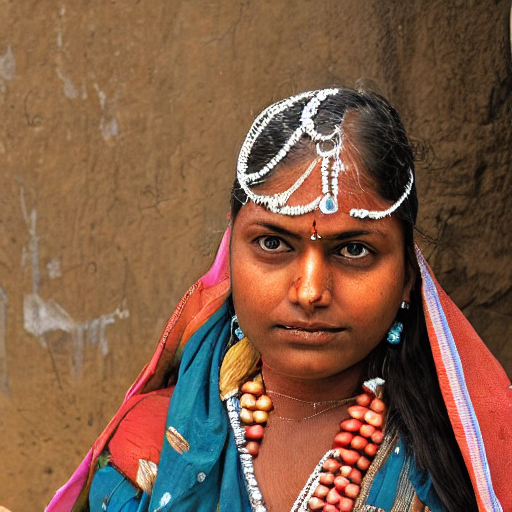

In [ ]:
#Loading base SD 1.5 (community mirror) and generate one baseline image.

import torch
from diffusers import StableDiffusionPipeline

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

prompt = "indian female"
generator = torch.Generator("cuda").manual_seed(42)  # fixed seed = reproducible sampler

baseline = pipe(prompt, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]
baseline.save("baseline_before_lora.png")
baseline  # displays inline

In [ ]:
 #injecting a FRESH LoRA adapter, load THE dataset.
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from diffusers import DDPMScheduler, UNet2DConditionModel
from peft import LoraConfig

device = "cuda"
weight_dtype = torch.float16
RANK = 8   # 4 / 8 / 16 —
DATASET_ID = "svjack/pokemon-blip-captions-en-zh"

# Reloading a CLEAN UNet every run -> no "adapter 'default' already exists" on re-runs.
pipe.unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder="unet", torch_dtype=torch.float16
).to("cuda")
pipe.enable_attention_slicing()

unet, vae, text_encoder, tokenizer = pipe.unet, pipe.vae, pipe.text_encoder, pipe.tokenizer
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

vae.requires_grad_(False); text_encoder.requires_grad_(False); unet.requires_grad_(False)

lora_config = LoraConfig(
    r=RANK, lora_alpha=RANK, init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
unet.add_adapter(lora_config)

for p in unet.parameters():
    if p.requires_grad:
        p.data = p.data.float()

unet.enable_gradient_checkpointing()
unet.train()

#Loading dataset
dataset = load_dataset(DATASET_ID, split="train")
cols = dataset.column_names
img_col = next(c for c in ["image", "img"] if c in cols)
txt_col = next(c for c in ["text", "caption", "en_text", "en"] if c in cols)
dataset = dataset.rename_columns({img_col: "image", txt_col: "text"})
print(f"LOADED {DATASET_ID} | {len(dataset)} rows | image='{img_col}' text='{txt_col}'")

res = 512
tf = transforms.Compose([
    transforms.Resize(res, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(res),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def preprocess(ex):
    ex["pixel_values"] = [tf(img.convert("RGB")) for img in ex["image"]]
    tok = tokenizer(ex["text"], max_length=tokenizer.model_max_length,
                    padding="max_length", truncation=True, return_tensors="pt")
    ex["input_ids"] = list(tok.input_ids)
    return ex

dataset = dataset.with_transform(preprocess)

def collate(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]).contiguous().float(),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
    }

loader = DataLoader(dataset, shuffle=True, batch_size=1, collate_fn=collate)
n_trainable = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"{n_trainable:,} trainable LoRA params (rank={RANK}) | dataset: {DATASET_ID}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


README.md:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

data/train-00000-of-00001-78e564002aa9c8(…): reconstructing file:   0%|          |  0.00B / 99.7MB            

data/train-00000-of-00001-78e564002aa9c8(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

LOADED svjack/pokemon-blip-captions-en-zh | 833 rows | image='image' text='en_text'
1,594,368 trainable LoRA params (rank=8) | dataset: svjack/pokemon-blip-captions-en-zh


In [ ]:
# Training loop.
lora_params = [p for p in unet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(lora_params, lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

max_train_steps = 100
losses = []
step = 0
while step < max_train_steps:
    for batch in loader:
        pixel_values = batch["pixel_values"].to(device, dtype=weight_dtype)
        input_ids = batch["input_ids"].to(device)

        # Frozen encoders -> no grad. VAE stays OUT of autocast: SD's VAE is numerically
        # twitchy in fp16 and can emit NaNs; no need to risk it since it's frozen.
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
            enc_hidden = text_encoder(input_ids)[0]

        noise = torch.randn_like(latents)
        t = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                          (latents.shape[0],), device=device).long()
        noisy = noise_scheduler.add_noise(latents, noise, t)

        with torch.autocast("cuda", dtype=torch.float16):
            pred = unet(noisy, t, enc_hidden).sample
            target = noise  # SD 1.5 is epsilon-prediction
            loss = F.mse_loss(pred.float(), target.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        optimizer.zero_grad()

        losses.append(loss.item())
        step += 1
        if step % 10 == 0:
            print(f"step {step:3d} | loss {loss.item():.4f}")
        if step >= max_train_steps:
            break

print(f"\ndone — first loss {losses[0]:.4f}  ->  last loss {losses[-1]:.4f}")

step  10 | loss 0.0035
step  20 | loss 0.0921
step  30 | loss 0.0032
step  40 | loss 0.0277
step  50 | loss 0.0406
step  60 | loss 0.0139
step  70 | loss 0.0195
step  80 | loss 0.0285
step  90 | loss 0.0220
step 100 | loss 0.0074

done — first loss 0.1528  ->  last loss 0.0074


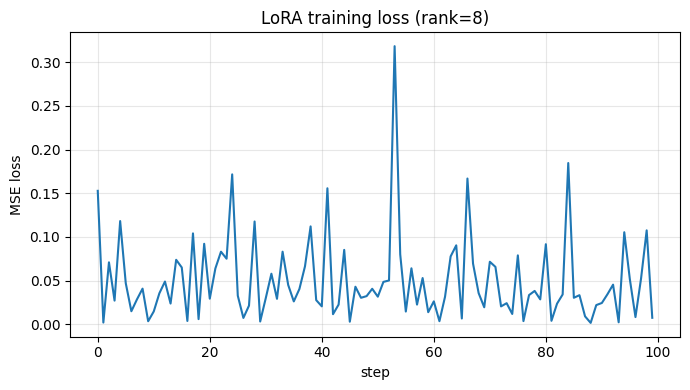

In [ ]:
#  Ploting the loss curve for your EVALUATION.md.
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("MSE loss"); plt.title(f"LoRA training loss (rank={RANK})")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"loss_curve_r{RANK}.png", dpi=120)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

image 0  seed 3174396576


  0%|          | 0/30 [00:00<?, ?it/s]

image 1  seed 3001713986


  0%|          | 0/30 [00:00<?, ?it/s]

image 2  seed 4023884034


  0%|          | 0/30 [00:00<?, ?it/s]

image 3  seed 3021684893

prompt: "a moster pokemon creature, sci-fi style"  ->  saved generated_grid.png


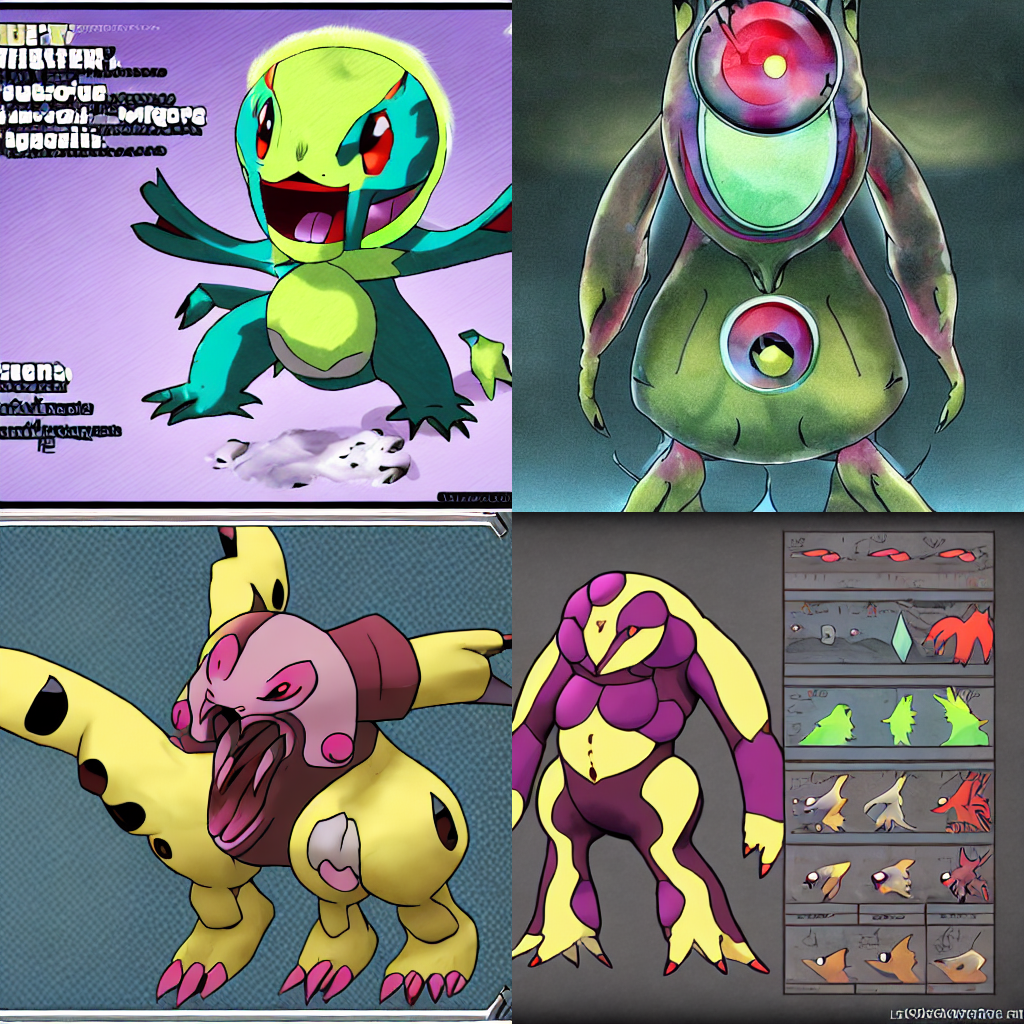

In [ ]:
# GENERATION — type a prompt and run. Uses the LoRA trained above (already on pipe.une).
import random
from PIL import Image

PROMPT      = "a moster pokemon creature, sci-fi style"   # <-- change this to whatever you want
NUM_IMAGES  = 4        # how many images to make
STEPS       = 30
GUIDANCE    = 7.5
SEED        = 42     # None = different each run; set an int (e.g. 42) for reproducible output

# If you RESTARTED the runtime and lost the in-memory adapter, uncomment to reload from disk:
# pipe.load_lora_weights(f"lora-r{RANK}")

pipe.unet.eval()

def image_grid(imgs, cols=2):
    rows = (len(imgs) + cols - 1) // cols
    imgs = imgs + [Image.new("RGB", imgs[0].size, "white")] * (rows * cols - len(imgs))
    w, h = imgs[0].size
    grid = Image.new("RGB", (cols * w, rows * h))
    for i, im in enumerate(imgs):
        grid.paste(im, (i % cols * w, i // cols * h))
    return grid

images = []
for i in range(NUM_IMAGES):
    seed = (SEED + i) if SEED is not None else random.randint(0, 2**32 - 1)

    g = torch.Generator("cuda").manual_seed(int(seed))
    img = pipe(PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    img.save(f"gen_{i}_seed{seed}.png")
    images.append(img)
    print(f"image {i}  seed {seed}")

grid = image_grid(images, cols=min(NUM_IMAGES, 2))
grid.save("generated_grid.png")
print(f'\nprompt: "{PROMPT}"  ->  saved generated_grid.png')
grid  # displays inline